# Logistic Regression

## Overview
Logistic Regression is a statistical method used for binary and multiclass classification problems. It models the probability that an instance belongs to a particular class using the logistic (sigmoid) function. The algorithm is based on linear regression but applies a sigmoid transformation to constrain output values between 0 and 1, making it suitable for probability estimation. Logistic Regression is widely used due to its simplicity, interpretability, and computational efficiency, especially for linearly separable data.

### Key Characteristics:
- **Type**: Supervised learning algorithm for classification
- **Output**: Probability values between 0 and 1
- **Decision Boundary**: Linear in the original feature space
- **Cost Function**: Cross-entropy (log loss)
- **Use Cases**: Binary classification, spam detection, disease prediction, customer churn analysis

In [58]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

# Add the libs directory to Python path
current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter1D, KalmanFilter2D

dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [59]:
with open(f"{models_dir}/turbine_data_model.pkl", 'rb') as file:
    model = pickle.load(file)

model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0. , 1.49, 0. ,...,-0.03, 0.13,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,231.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.67e+08,2.23e+05,1.30e+04,...,1.99e+01,6.03e+00,0.00e+00]"


In [60]:
df = pd.read_csv(f"{dataset_dir}/Turbine_Data.csv")

df = df[['ActivePower']]
df = df.dropna()
df = df.drop_duplicates()

df.head()

,ActivePower
144,-5.357727
145,-5.822360
146,-5.279409
147,-4.648054
148,-4.684632


In [61]:
df.describe()

,ActivePower
count,94084.000000
mean,622.427076
std,610.819943
min,-38.524659
25%,84.379938
50%,407.476558
75%,1079.815653
max,1779.032433


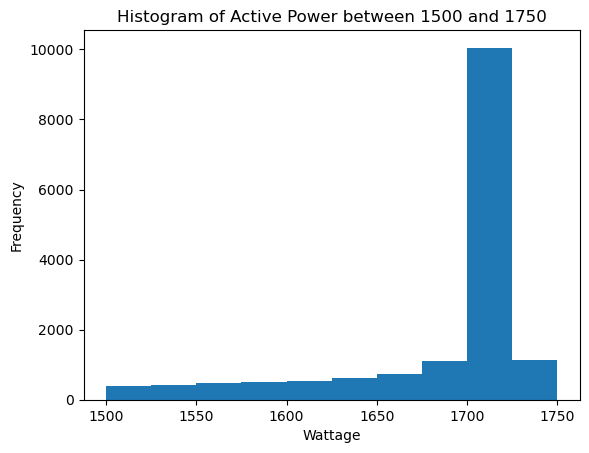

In [62]:
plt.Figure((10, 6))

plt.hist(df, range=(1500, 1750))
plt.title("Histogram of Active Power between 1500 and 1750")
plt.xlabel("Wattage")
plt.ylabel("Frequency")

plt.show()

In [63]:
X = np.array(df['ActivePower'])
X = X[X > 0]
y = np.array([ abs(int(x // 1500)) for x in X])

X = X.reshape(-1, 1)

print(f"Classes in Y = {np.unique(y)}")

Classes in Y = [0 1]


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression solvers in scikit-learn: concise reference
Keys: solver name -> (supported penalties, multinomial support, best use-case / notes)

```
LOGREG_SOLVERS = {
    "liblinear": {
        "penalties": ["l1", "l2"],
        "multinomial": False,  # handles one-vs-rest for multiclass
        "notes": "Good for small datasets and binary problems. Uses liblinear (coordinate descent). Not suitable for large datasets."
    },
    "newton-cg": {
        "penalties": ["l2"],
        "multinomial": True,
        "notes": "Second-order (Newton) method. Works well for multiclass (multinomial) with L2; can be slower on very large datasets."
    },
    "lbfgs": {
        "penalties": ["l2"],
        "multinomial": True,
        "notes": "Quasi-Newton optimizer. Default solver in many settings; robust and often fast for medium-sized problems. Supports only L2."
    },
    "sag": {
        "penalties": ["l2"],
        "multinomial": True,
        "notes": "Stochastic Average Gradient. Fast on large datasets (needs many samples), requires feature scaling. Supports only L2."
    },
    "saga": {
        "penalties": ["l1", "l2", "elasticnet"],
        "multinomial": True,
        "notes": "Variant of SAG that supports L1 and elastic-net. Good for large-scale problems and sparse data; supports multinomial and regularizers like elasticnet."
    }
}
```

Usage tip:
- Default solver is typically 'lbfgs' (supports multinomial, L2).
- Choose 'liblinear' for small/binary problems needing L1.
- Choose 'saga' if you need L1/elasticnet on large/sparse data.
- Scale features when using 'sag' or 'saga' for best convergence.


In [65]:
model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Evaluate the Model

In [66]:
# R-squared value
r2_train = r2_score(y_train, y_train)
print(f"R-squared for {model.__class__.__name__} Train: {r2_train:.4f}")

r2_test = r2_score(y_test, y_test)
print(f"R-squared for {model.__class__.__name__} Test: {r2_test:.4f}")

# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train)
print(f"Mean Squared Error for {model.__class__.__name__} Train: {mse_train:.4f}")

mse_test = mean_squared_error(y_test, y_test)
print(f"Mean Squared Error for {model.__class__.__name__} Test: {mse_test:.4f}")

R-squared for LogisticRegression Train: 1.0000
R-squared for LogisticRegression Test: 1.0000
Mean Squared Error for LogisticRegression Train: 0.0000
Mean Squared Error for LogisticRegression Test: 0.0000


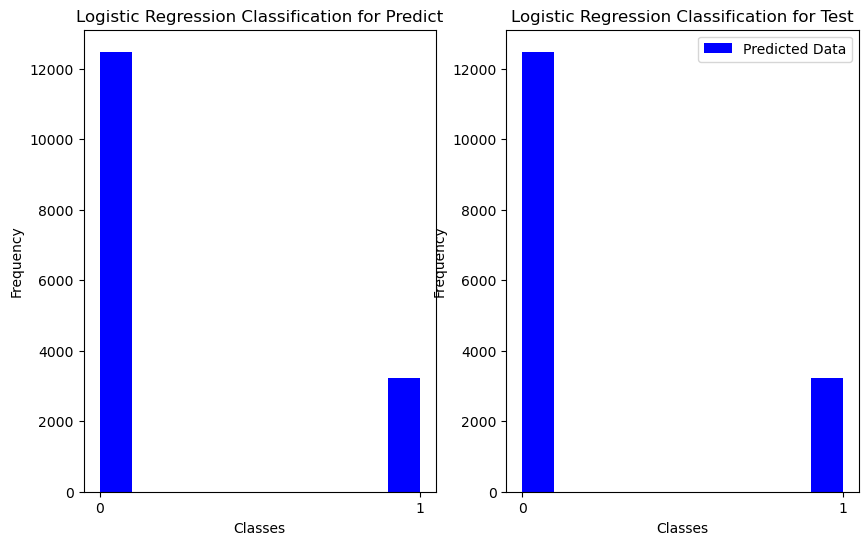

In [67]:
# Visualize the model's predictions
plt.figure(figsize=[10,6])

plt.subplot(1,2,1)
plt.hist(model.predict(X_test), color='blue', label='Predicted Data',range=[0,1])
plt.xticks([0, 1])
plt.title('Logistic Regression Classification for Predict')
plt.xlabel('Classes')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(y_test, color='blue', label='Predicted Data',range=[0,1])
plt.xticks([0, 1])
plt.title('Logistic Regression Classification for Test')
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [76]:
X_data = np.sort(X_test,axis=0)
y_data = model.predict(X_data)

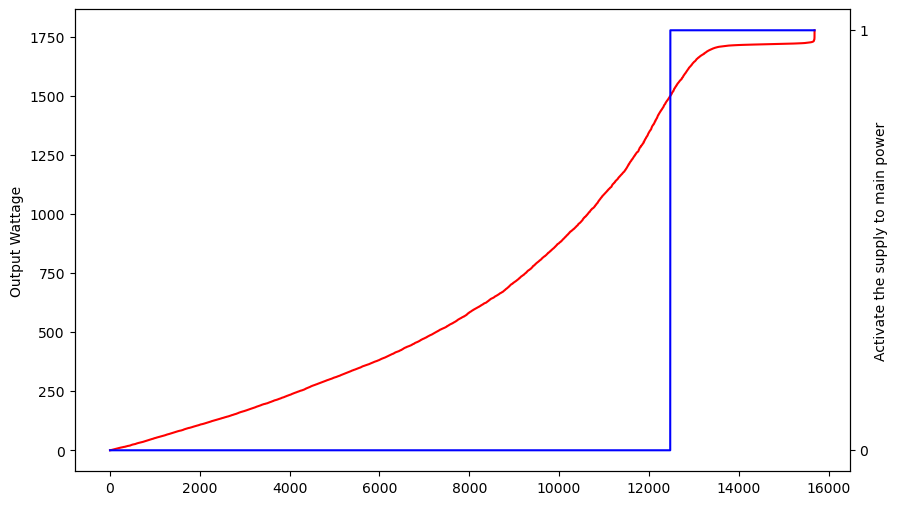

In [82]:
plt.figure(figsize=[10,6])
plt.plot(X_data, color='red')
plt.tick_params(axis='y')
plt.ylabel("Output Wattage")

plt.twinx()
plt.plot(y_data, color='blue')
plt.tick_params(axis='y')
plt.ylabel("Activate the supply to main power")
plt.yticks([0,1])

plt.show()